In [1]:
from datascience import *
%matplotlib inline
path_data = 'data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import math
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# SD와 정규 곡선

우리는 평균이 히스토그램의 균형점이라는 것을 알고 있습니다. 평균과 달리, SD는 일반적으로 히스토그램을 보고 식별하기 쉽지 않습니다.

그러나 SD가 평균만큼이나 명확하게 식별될 수 있는 분포 모양이 있습니다. 바로 종 모양 분포입니다. 이 절에서는 확률 히스토그램과 일부 데이터 히스토그램에서 자주 나타나는 그 모양을 살펴봅니다.

## 대략 종 모양인 데이터 히스토그램
우리가 익숙한 1,174쌍의 산모-신생아 표본에서 산모의 키 분포를 살펴봅시다. 산모들의 키는 평균 64인치이고 SD는 2.5인치입니다. 농구 선수들의 키와 달리, 산모들의 키는 종 모양 곡선에서 평균을 중심으로 상당히 대칭적으로 분포되어 있습니다.

In [3]:
baby = Table.read_table(path_data + 'baby.csv')

In [4]:
baby

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [5]:
heights = baby.column('Maternal Height')
mean_height = np.round(np.mean(heights), 1)
mean_height

64.0

In [6]:
sd_height = np.round(np.std(heights), 1)
sd_height

2.5

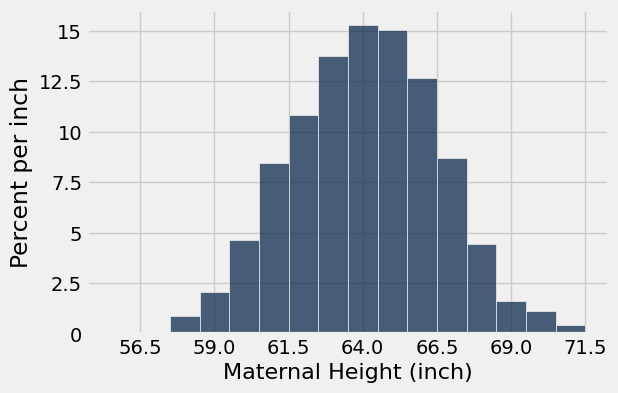

In [7]:
baby.hist('Maternal Height', bins=np.arange(55.5, 72.5, 1), unit='inch')
positions = np.arange(-3, 3.1, 1)*sd_height + mean_height
plots.xticks(positions);

위 셀의 마지막 두 줄의 코드는 가로축의 레이블을 변경합니다. 이제 레이블은 $z = 0, \pm 1, \pm 2$, 그리고 $\pm 3$에 대해 "평균 $\pm$ $z$ SD"에 해당합니다. 분포의 모양 때문에, "중심"은 모호하지 않은 의미를 가지며 64에서 명확하게 보입니다.

## 종 모양 곡선에서 SD 찾기

SD가 곡선과 어떻게 관련되어 있는지 보려면, 곡선의 꼭대기에서 시작하여 오른쪽을 바라보세요. 곡선이 "뒤집힌 컵" 모양에서 "제대로 된 컵" 모양으로 바뀌는 곳이 있습니다; 공식적으로, 곡선은 변곡점을 가집니다. 그 점은 평균보다 1 SD 위입니다. 그것은 $z=1$인 점으로, "평균 더하기 1 SD" = 66.5인치입니다.

평균의 왼쪽에서 대칭적으로, 변곡점은 $z=-1$에 있으며, 즉 "평균 빼기 1 SD" = 61.5인치입니다.

일반적으로, **종 모양 분포의 경우, SD는 평균과 양쪽의 변곡점 사이의 거리입니다.**

## 표준 정규 곡선

우리가 본 모든 종 모양 히스토그램은 축의 레이블을 제외하면 본질적으로 같아 보입니다. 실제로, 축을 적절하게 다시 레이블링하면 이러한 모든 곡선을 그릴 수 있는 하나의 기본 곡선이 있습니다.

그 기본 곡선을 그리기 위해, 우리는 모든 리스트를 변환할 수 있는 단위인 표준 단위를 사용할 것입니다. 따라서 결과 곡선을 *표준 정규 곡선*이라고 합니다.

표준 정규 곡선은 인상적인 방정식을 가지고 있습니다. 하지만 지금은 표준 단위로 측정되고 종 모양 분포를 가진 변수의 히스토그램의 부드러운 윤곽선으로 생각하는 것이 가장 좋습니다.

$$
\phi(z) = {\frac{1}{\sqrt{2 \pi}}} e^{-\frac{1}{2}z^2}, ~~ -\infty < z < \infty
$$

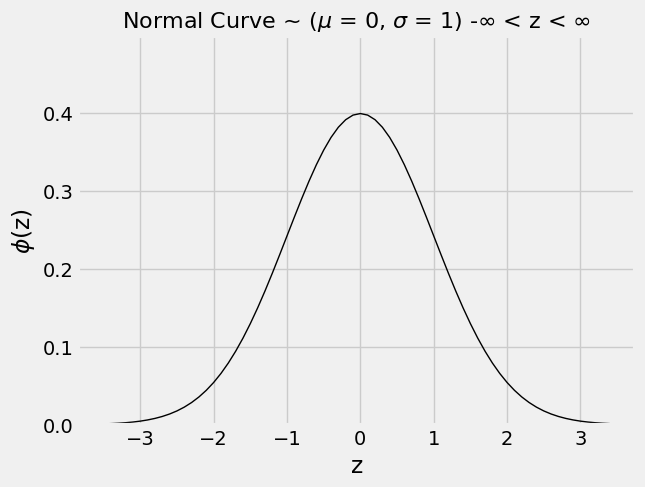

In [8]:
# The standard normal curve

plot_normal_cdf()

새로운 히스토그램을 살펴볼 때 항상 그렇듯이, 가로축을 먼저 봅니다. 표준 정규 곡선의 가로축에서 값은 표준 단위입니다.

여기 곡선의 몇 가지 속성이 있습니다. 일부는 관찰로 명백하고, 다른 것들은 확립하기 위해 상당한 양의 수학이 필요합니다.

- 곡선 아래의 총 면적은 1입니다. 따라서 밀도 척도로 그려진 히스토그램으로 생각할 수 있습니다.

- 곡선은 0에 대해 대칭입니다. 따라서 변수가 이 분포를 가지면, 평균과 중앙값은 모두 0입니다.

- 곡선의 변곡점은 -1과 +1에 있습니다.

- 변수가 이 분포를 가지면, SD는 1입니다. 정규 곡선은 히스토그램에서 SD가 매우 명확하게 식별되는 몇 안 되는 분포 중 하나입니다.

곡선을 부드러운 히스토그램으로 생각하고 있으므로, 곡선 아래의 면적으로 전체 데이터 양의 비율을 나타내고자 합니다.

부드러운 곡선 아래의 면적은 종종 적분이라는 방법을 사용하여 미적분학으로 찾습니다. 그러나 수학적 사실로, 표준 정규 곡선은 미적분학의 일반적인 방법으로 적분할 수 없습니다.

따라서 곡선 아래의 면적은 근사되어야 합니다. 그래서 거의 모든 통계학 교과서에는 정규 곡선 아래의 면적 표가 있습니다. 또한 Python의 모듈을 포함한 모든 통계 시스템이 그 면적에 대한 훌륭한 근사값을 제공하는 메서드를 포함하는 이유입니다.

In [9]:
from scipy import stats

## 표준 정규 "cdf"

정규 곡선 아래의 면적을 찾는 기본 함수는 `stats.norm.cdf`입니다. 이 함수는 숫자 인수를 받아 그 숫자의 왼쪽에 있는 곡선 아래의 모든 면적을 반환합니다. 공식적으로, 이것은 표준 정규 곡선의 "누적 분포 함수"라고 합니다. 그 다소 다루기 힘든 이름은 cdf로 약칭됩니다.

이 함수를 사용하여 표준 정규 곡선 아래 $z=1$의 왼쪽 면적을 찾아봅시다.

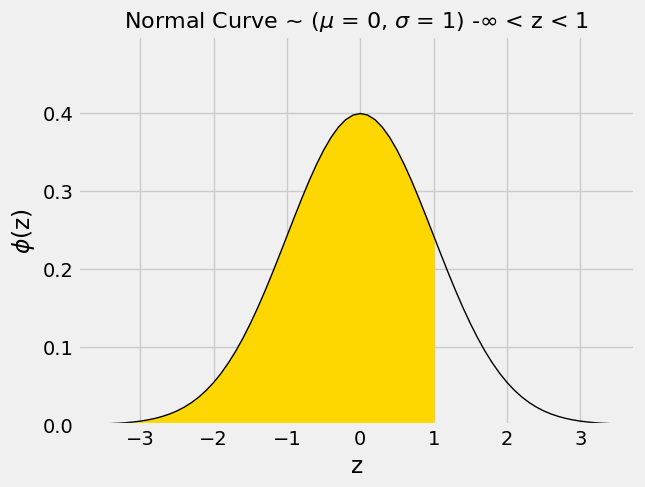

In [10]:
# Area under the standard normal curve, below 1

plot_normal_cdf(1)

음영 처리된 면적의 수치 값은 `stats.norm.cdf`를 호출하여 찾을 수 있습니다.

In [11]:
stats.norm.cdf(1)

0.84134474606854293

약 84%입니다. 이제 곡선의 대칭성과 곡선 아래의 총 면적이 1이라는 사실을 사용하여 다른 면적을 찾을 수 있습니다.

$z=1$의 오른쪽 면적은 약 100% - 84% = 16%입니다.

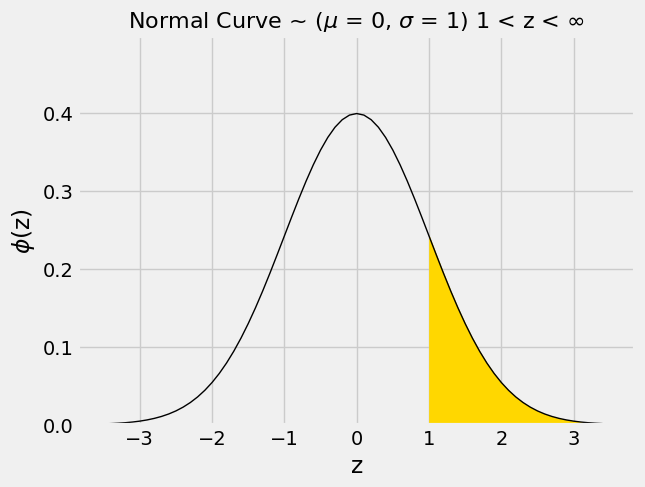

In [12]:
# Area under the standard normal curve, above 1

plot_normal_cdf(lbound=1)

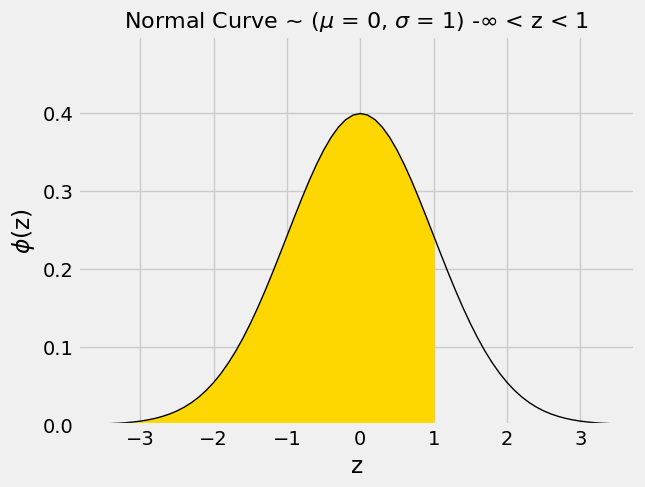

In [13]:
# Area under the standard normal curve, above 1

plot_normal_cdf(rbound=1)

In [14]:
1 - stats.norm.cdf(1)

0.15865525393145707

$z=-1$과 $z=1$ 사이의 면적은 여러 가지 방법으로 계산할 수 있습니다. 이것은 아래 곡선 아래의 금색 면적입니다.

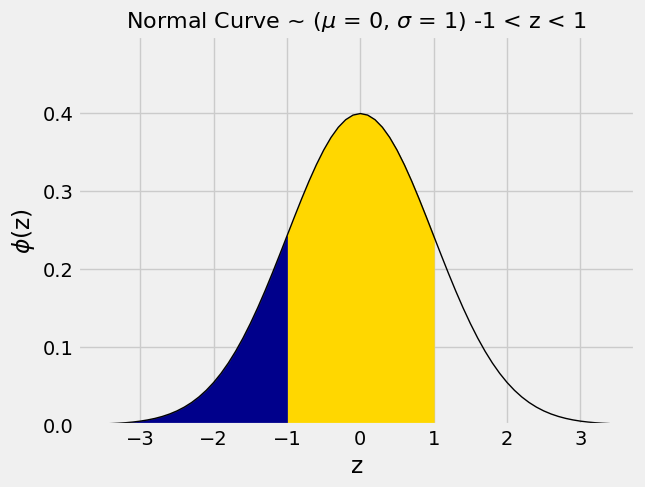

In [15]:
# Area under the standard normal curve, between -1 and 1

plot_normal_cdf(1, lbound=-1)

예를 들어, 면적을 "100% - 두 개의 동일한 꼬리"로 계산할 수 있으며, 이는 대략 100% - 2x16% = 68%가 됩니다.

또는 $z=1$과 $z=-1$ 사이의 면적은 $z=1$의 왼쪽에 있는 모든 면적에서 $z=-1$의 왼쪽에 있는 모든 면적을 뺀 것과 같다는 것을 알 수 있습니다.

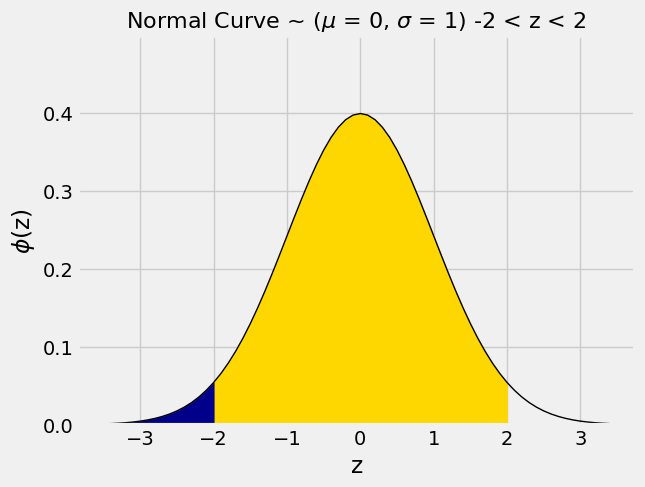

In [16]:
plot_normal_cdf(lbound=-2, rbound=2)

In [17]:
stats.norm.cdf(1) - stats.norm.cdf(-1)

0.68268949213708585

비슷한 계산으로, $-2$와 2 사이의 면적은 약 95%임을 알 수 있습니다.

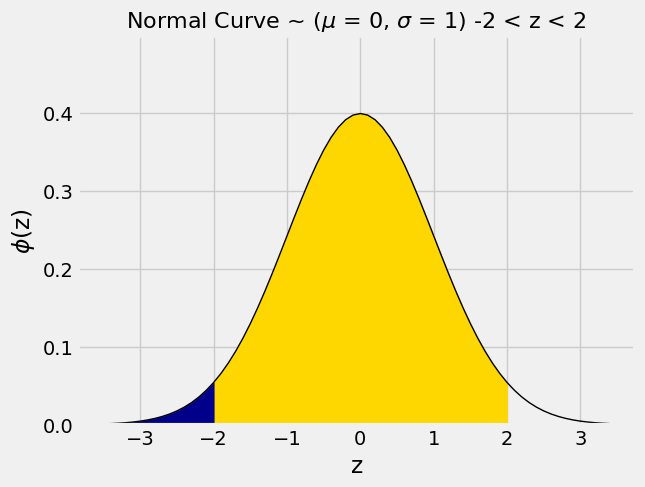

In [18]:
# Area under the standard normal curve, between -2 and 2

plot_normal_cdf(2, lbound=-2)

In [19]:
stats.norm.cdf(2) - stats.norm.cdf(-2)

0.95449973610364158

다시 말해, 히스토그램이 대략 종 모양이면, "평균 $\pm$ 2 SD" 범위에 있는 데이터의 비율은 약 95%입니다.

이것은 체비쇼프의 하한 75%보다 상당히 많습니다. 체비쇼프의 경계는 모든 분포에 대해 작동해야 하므로 더 약합니다. 분포가 정규 분포임을 알면, 경계뿐만 아니라 비율에 대한 좋은 근사값을 얻을 수 있습니다.

아래 표는 모든 분포와 정규 분포에 대해 우리가 아는 것을 비교합니다. $z=1$일 때, 체비쇼프의 경계는 맞지만 정보를 주지 않는다는 것에 주목하세요.

| 범위 내 퍼센트      | 모든 분포: 경계            | 정규 분포: 근사값                  |
| :---------------    | :------------------------  | :--------------------------------- |
| 평균 $\pm$ 1 SD     | 적어도 0%                  | 약 68%                             |
| 평균 $\pm$ 2 SD     | 적어도 75%                 | 약 95%                             |
| 평균 $\pm$ 3 SD     | 적어도 88.888...%          | 약 99.73%                          |